# 7.Training a convonutional neural network

**Cnn explainer - https://poloclub.github.io/cnn-explainer/**

### Setting up the dataset


In [2]:
import torch 
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import pandas as pd 
import matplotlib.pyplot as plt 
#setting up training data
train_data = datasets.FashionMNIST(
    root= "data", #Where to download data to ?
    train= True, #Do we want the training dataset
    download = True, # Do we want to download the dataset
    transform= ToTensor(), #Transform the images into tensors
    target_transform= None # Do we want to transform the labels 


)

test_data = datasets.FashionMNIST(
    root = "data" ,
    train = False , #testing dataset
    download=True,
    transform= ToTensor(),
    target_transform = None

)

In [3]:
from torch.utils.data import DataLoader
#Setup the batch size hyperparameter
BATCH_SIZE = 32
train_dataloader = DataLoader(batch_size = BATCH_SIZE,dataset = train_data,shuffle = True)
test_dataloader = DataLoader(batch_size = BATCH_SIZE,dataset = test_data,shuffle = False)
train_dataloader , test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x2792dc97130>,
 <torch.utils.data.dataloader.DataLoader at 0x2792dc97370>)

In [4]:
train_features_batch ,train_labels_batch  = next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape


(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

![ss.png](<ss.png>)

# Model:2 Convonutional Neural network 

CNN'S are also known as ConvNets.

CNN's are known for their capabilities to find patterns in visual data



In [6]:
from torch import device
device = "cuda"if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
#Creating a CNN
class MNIST_modelv2(nn.Module):
    """ Model that replicates the TinyVGG """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            #kernel_size = area of pixels it will learn
            #stride = how many pixels it will move
            #padding = used to reduce aviod shrinkage of the image CNNS are learning
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) #only maps the strongest feature from the nn.conv2d's kernel 
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        #print(f"output shape of conv block 1 :{x.shape}")
        x = self.conv_block_2(x)
        #print(f"output shape of conv block 2 : {x.shape}")
        x = self.classifier(x)
        #print(f"Output shape of classifier {x.shape}")
        return x

In [8]:
rand_image_tensor = torch.randn(size=(1,28,28))


In [9]:
torch.manual_seed(42)

model_2 = MNIST_modelv2(input_shape=1,hidden_units=10,output_shape=len(class_names)).to(device)

## 7.1  stepping through nn.conv2d()

In [10]:
torch.manual_seed(42)
#Creating a batch of images
images = torch.randn(size=(32,3,64,64))
test_image = images[0]

print(f"Image batch shape{images.shape}")

Image batch shapetorch.Size([32, 3, 64, 64])


In [11]:
#Creat a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3,out_channels=10,kernel_size=3, stride=1,padding=0)
#pass the data through the covolution layer
conv_output = conv_layer(test_image)
conv_output

tensor([[[-2.8778e-01, -6.0596e-02, -5.6306e-02,  ...,  2.8654e-01,
           6.6224e-01, -2.3216e-01],
         [-9.8911e-01, -4.0099e-01,  4.1832e-01,  ...,  4.7459e-01,
          -1.8552e-01, -5.7622e-01],
         [-4.1340e-02, -2.3277e-01,  3.7418e-01,  ...,  2.8255e-02,
           1.4923e-01,  1.4236e-01],
         ...,
         [-8.0374e-01, -7.6687e-01, -5.9457e-02,  ...,  1.7452e-01,
           4.2594e-01, -4.8341e-01],
         [-1.4512e-01, -1.1566e-01,  6.1783e-01,  ...,  2.4126e-01,
          -3.6626e-01,  3.5645e-01],
         [ 3.6096e-02,  1.5214e-01,  2.3123e-01,  ...,  3.0904e-01,
          -4.9680e-01, -7.2258e-01]],

        [[-1.0853e+00, -1.6079e+00,  1.3346e-01,  ...,  2.1698e-01,
          -1.7643e+00,  2.5263e-01],
         [-8.2507e-01,  6.3866e-01,  1.8845e-01,  ..., -1.0936e-01,
           4.8068e-01,  8.4869e-01],
         [ 6.4927e-01, -4.2061e-03, -4.9991e-01,  ...,  5.8356e-01,
           2.4611e-01,  6.6233e-01],
         ...,
         [ 9.8860e-02,  1

## 7.2 Stepping through `nn.Maxpool2d()`

In [12]:
#Print out original image shape wihtout unsqueezed dimension
print(f"Test image original shape :{test_image.shape}")
print(f"Test image with unsqueezed dimension:{test_image.unsqueeze(0).shape}")

#Create a sample nn.Maxpool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size = 2)
#Pass data through just the conv layer
test_image_through_conv = conv_layer(test_image.unsqueeze(0))
print(f"Shape after going through conv_layer() : {test_image_through_conv.shape}")
#pass data through the max pool layer
test_image_through_conv_and_maxpool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer and max_pool_layer(): {test_image_through_conv_and_maxpool.shape} ")


Test image original shape :torch.Size([3, 64, 64])
Test image with unsqueezed dimension:torch.Size([1, 3, 64, 64])
Shape after going through conv_layer() : torch.Size([1, 10, 62, 62])
Shape after going through conv_layer and max_pool_layer(): torch.Size([1, 10, 31, 31]) 


In [13]:
torch.manual_seed(42)
#Creating a random tensor with a similar number of dimensions of our images
random_tensor = torch.randn(size = (1,1,2,2))
print(f"\nrandom tensor :\n {random_tensor}")
print(f"\nRandom tensor shape : \n{random_tensor.shape}")
#Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor :\n{max_pool_tensor}")
print(f"\nMax pool tensor shape : \n{max_pool_tensor.shape}")
random_tensor


random tensor :
 tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

Random tensor shape : 
torch.Size([1, 1, 2, 2])

Max pool tensor :
tensor([[[[0.3367]]]])

Max pool tensor shape : 
torch.Size([1, 1, 1, 1])


tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

In [14]:
image , label =  train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

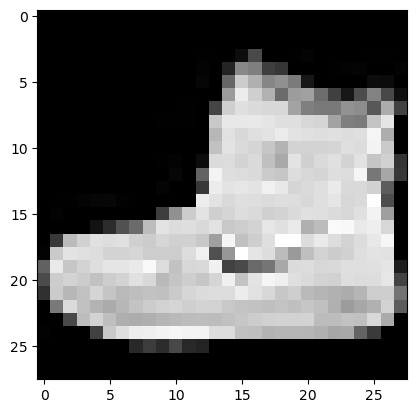

In [15]:
plt.imshow(image.squeeze(),cmap= 'gray')


In [16]:
#Pass image through model
model_2.to(device)
image = image.to(device)
model_2(image.unsqueeze(0))

tensor([[ 0.0246, -0.0644,  0.0551, -0.0360, -0.0139,  0.0113, -0.0014, -0.0075,
          0.0213,  0.0076]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [17]:
rand_img_tesnor = torch.randn(size = (1,28,28))
rand_image_tensor.shape
rand_image_tensor = rand_image_tensor.to(device)

In [18]:
model_2(rand_image_tensor.unsqueeze(0))

tensor([[ 0.0277, -0.0997,  0.0724, -0.0374,  0.0041,  0.0292,  0.0096,  0.0065,
          0.0055, -0.0225]], device='cuda:0', grad_fn=<AddmmBackward0>)

#  How the CNN Makes a Decision: Step-by-Step

Understanding a Convolutional Neural Network (CNN) is much easier when we track the **shape of the data** as it travels through the model. Our model is divided into two main teams: the **Feature Extractors** (Conv Blocks) and the **Detective** (Linear Classifier).

Here is exactly what happens when we pass a single image into the network.

---

### 1. The Input: The Raw Image
We start with a single image tensor. 
* **Shape:** `[1, 1, 28, 28]` (or similar depending on padding/resizing)
* **Meaning:** `[Batch Size, Channels, Height, Width]`. We are looking at 1 grayscale image that is a 2D grid of pixels.

---

### 2. The Feature Extractors (Conv Blocks 1 & 2)
The image enters our convolutional layers. These layers act like magnifying glasses scanning the image for visual patterns (edges, corners, loops).

* **After `conv_block_1`:** * **Shape:** `[1, 10, 14, 14]`
  * **What happened?** The network applied 10 different filters (creating 10 "feature maps") to look for basic patterns. The `MaxPool2d` layer shrank the image dimensions in half to save memory and keep only the strongest features.
* **After `conv_block_2`:**
  * **Shape:** `[1, 10, 7, 7]`
  * **What happened?** The network scanned those basic patterns to find more complex shapes. The second `MaxPool2d` shrank the height and width in half again. We now have 10 maps, each 7x7 in size, showing exactly where clues were found in 2D space.

---

### 3. The Bridge: `nn.Flatten()`
The Convolutional blocks need 2D space to find shapes, but our final Classifier only understands flat lists. We have to build a bridge between them.

* **What happens?** The `Flatten` layer destroys the 2D spatial grid. It takes our 10 maps of 7x7 pixels and unrolls them into one massive, single-file line of numbers.
* **The Math:** $10 \times 7 \times 7 = 490$
* **The Result:** Our image is no longer a picture; it is now a 1D checklist of **490 individual clues** (features).

---

### 4. The Verdict: The Linear Classifier
The data enters the `nn.Linear` layer. This layer acts as the detective. It does not understand spatial dimensions; it just looks at the 490 clues and calculates a weighted score for our target classes.

* **Final Output Shape:** `[1, 10]`
* **Meaning:** `[Batch Size, Number of Classes]`. 
* **The Result:** The model gives us a list of 10 raw scores (logits). Each number represents the model's confidence that the image belongs to a specific category (e.g., T-shirt, Trouser, Sneaker). The index with the highest score is our final prediction!

---

### 7.3 Setup loss function and optimizer for fashionMNIST dataset

In [19]:
from helper_function import accuracy_fn , print_train_time
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_2.parameters(),lr = 0.1)


### 7.4 Training and testing model_2

In [20]:
device = 'cuda' if torch.cuda.is_available() else'cpu'
device

'cuda'

In [21]:
from train_test import train_step,test_step,eval_model
from tqdm.auto import tqdm
torch.manual_seed(42)
from helper_function import print_train_time
from timeit import default_timer as timer 

start = timer()
model_2.to(device)
epochs = 3 
for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch +1}\n---------")
    train_step(model=model_2,train_dataloader=train_dataloader,loss_fn=loss_fn,optimizer= optimizer,accuracy_fn= accuracy_fn,device= device)
    test_step(model_2,test_dataloader,loss_fn,accuracy_fn,device)


end = timer()
time_model2 = print_train_time(start,end,device = str(next(model_2.parameters()).device))



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 1
---------
Batch : 0/60000 
Batch : 12800/60000 
Batch : 25600/60000 
Batch : 38400/60000 
Batch : 51200/60000 
Train loss:0.60544|Train acc:78.01%
Test loss: 0.40824 | Test acc: 85.63%

Epoch : 2
---------
Batch : 0/60000 
Batch : 12800/60000 
Batch : 25600/60000 
Batch : 38400/60000 
Batch : 51200/60000 
Train loss:0.36039|Train acc:86.96%
Test loss: 0.35696 | Test acc: 87.14%

Epoch : 3
---------
Batch : 0/60000 
Batch : 12800/60000 
Batch : 25600/60000 
Batch : 38400/60000 
Batch : 51200/60000 
Train loss:0.32303|Train acc:88.32%
Test loss: 0.32171 | Test acc: 88.65%


Train time on cuda:0: 23.125 seconds


In [22]:
model_2_results = eval_model(model_2,test_dataloader,loss_fn,accuracy_fn)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'MNIST_modelv2',
 'model_loss': 0.3217141926288605,
 'model_acc': 88.64816293929712}

In [23]:
import pandas as pd
compare_results = pd.DataFrame([['MNISTmodel_v0',0.4302609860897064,84.9416666666666]
                                ,['MNISTmodel_v1',0.4857630431652069,82.7376198083067],
                                ['MNIST_modelv2',0.3217141926288605,88.64816293929712]],columns=["Model","Loss","Accuracy"])
compare_results

,Model,Loss,Accuracy
0,MNISTmodel_v0,0.430261,84.941667
1,MNISTmodel_v1,0.485763,82.737620
2,MNIST_modelv2,0.321714,88.648163


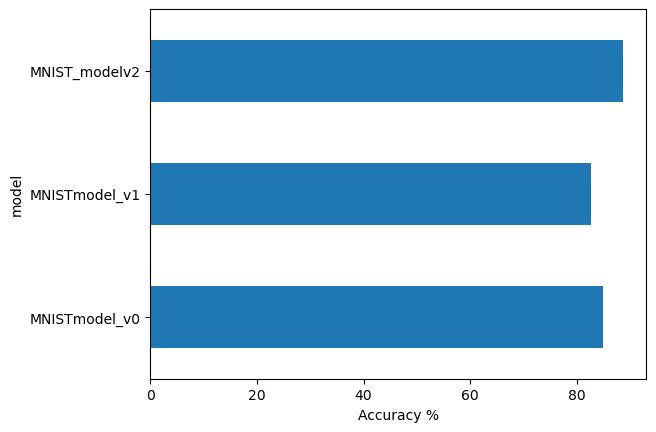

In [24]:
compare_results.set_index("Model")["Accuracy"].plot(kind="barh")
plt.xlabel("Accuracy %")
plt.ylabel("model")
plt.show()

## 9. Make and evaluate random predictions with best model

In [25]:
def make_predictions(model:torch.nn.Module,data:list,device:torch.device = device):
    pred_probs = []
    model.eval()
    model.to(device)
    with torch.inference_mode():
        for sample in data:
            #prepare the sample
            sample = torch.unsqueeze(sample,dim=0).to(device)
            #Forward pass
            pred_logit = model(sample)
            #Get prediction probabilties
            pred_prob = torch.softmax(pred_logit.squeeze(),dim=0)
            #Get pred prob off the GPU for further calculations 
            pred_probs.append(pred_prob.cpu())
    #Stack the pred prob to turn it into a tensor
    return torch.stack(pred_probs)



In [26]:
img,label = test_data[0][:10]
img.shape,label

(torch.Size([1, 28, 28]), 9)

In [27]:
import random
random.seed(12)
test_samples = []
test_labels = []
for sample,label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

    #View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Bag')

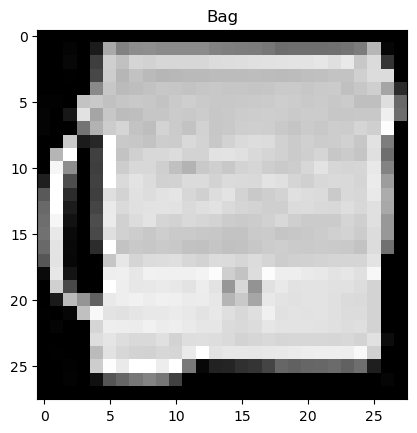

In [28]:
plt.imshow(test_samples[0].squeeze(),cmap='grey')
plt.title(class_names[test_labels[0]])

In [29]:
#Make predictions
pred_probs = make_predictions(model= model_2,data=test_samples)
#View the first 2 prediciton probabilities
pred_probs[:2]

tensor([[1.0111e-04, 8.4058e-06, 1.9147e-04, 5.7997e-06, 8.7823e-05, 8.8680e-07,
         4.1620e-04, 9.0907e-07, 9.9915e-01, 3.4908e-05],
        [4.2818e-04, 7.4849e-04, 8.2839e-06, 1.8220e-03, 1.1559e-03, 2.9236e-05,
         9.9521e-03, 5.0190e-05, 9.8581e-01, 4.7567e-08]])

In [30]:
test_labels

[8, 8, 2, 9, 0, 6, 0, 7, 0]

In [31]:
#Covert predcition probabilities to labels
pred_classes =  pred_probs.argmax(dim = 1)
pred_classes 

tensor([8, 8, 0, 9, 0, 6, 0, 7, 0])

In [32]:
test_labels

[8, 8, 2, 9, 0, 6, 0, 7, 0]

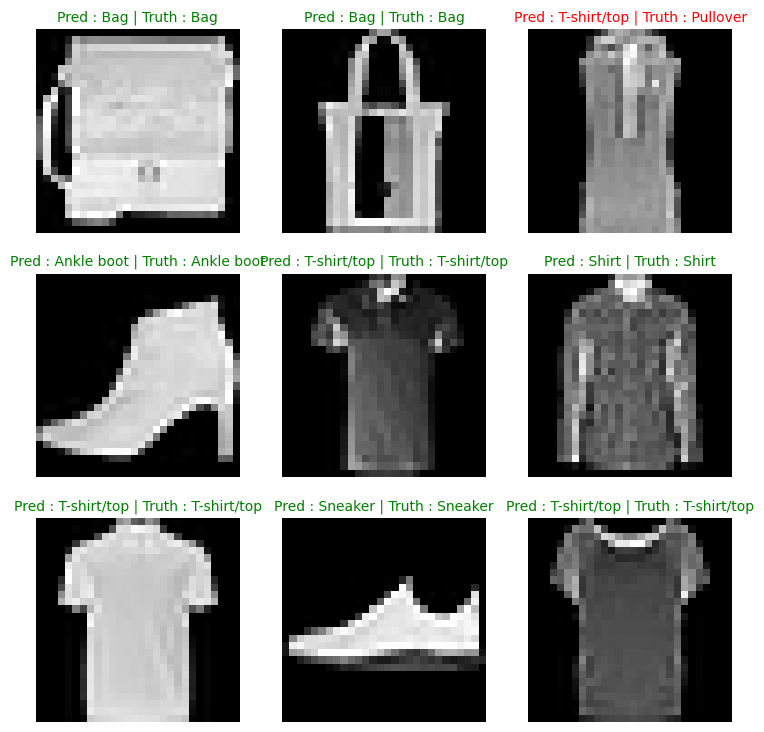

In [33]:
#Plot predictions
plt.figure(figsize=(9,9))
nrows = 3 
ncols = 3
for i, sample in enumerate(test_samples):
    #Create subplot
    plt.subplot(nrows,ncols,i+1)
    #Plot the target images
    plt.imshow(sample.squeeze(),cmap='gray')
    #Find the predction in text form
    pred_label = class_names[pred_classes[i]]

    #Get the truth label (in text form)
    truth_label = class_names[test_labels[i]]

    #Create a title for the plot
    title_text = f"Pred : {pred_label} | Truth : {truth_label}"

    #Check for equality between pred and truth and change color of title text
    if pred_label == truth_label:
        plt.title(title_text , fontsize = 10 , c = 'g' )    
    else:
        plt.title(title_text,fontsize = 10, c = 'r')
    plt.axis(False);



## 10.Making a confusion matrix
confusion matrix is one of the best ways to evaluate a classification model
1. make predictions with out trained model on the test dataset

2.Make a confusion matrix `torch.metrics.ConfusionMatrix`

3.Plot the confusin matrix using `mlextend.plotting.plt_confusion_matrix()`

In [34]:
from tqdm.auto import tqdm
#1.Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
    for X,y in tqdm(test_dataloader,desc='Making predictions...'):
        # send data and target to target device
        X,y = X.to(device), y.to(device)
        #Do the forward pass
        y_logit = model_2(X)
        #Turn predictions from logits -> predcition probabilites -> predcition labels
        y_pred = torch.softmax(y_logit.squeeze(),dim = 0).argmax(dim=1) 
        #Softmax converts logits into probabilities and armgmax finds the maximum probability value across dimension 1

        #Put predictions on cpu for plotting and evaluation
        y_preds.append(y_pred.cpu())
#Concatenate list of predctions
#print(y_preds)
y_preds_tensor = torch.cat(y_preds)
y_preds_tensor[:10]


Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [36]:
test_data.targets

tensor([9, 2, 1,  ..., 8, 1, 5])

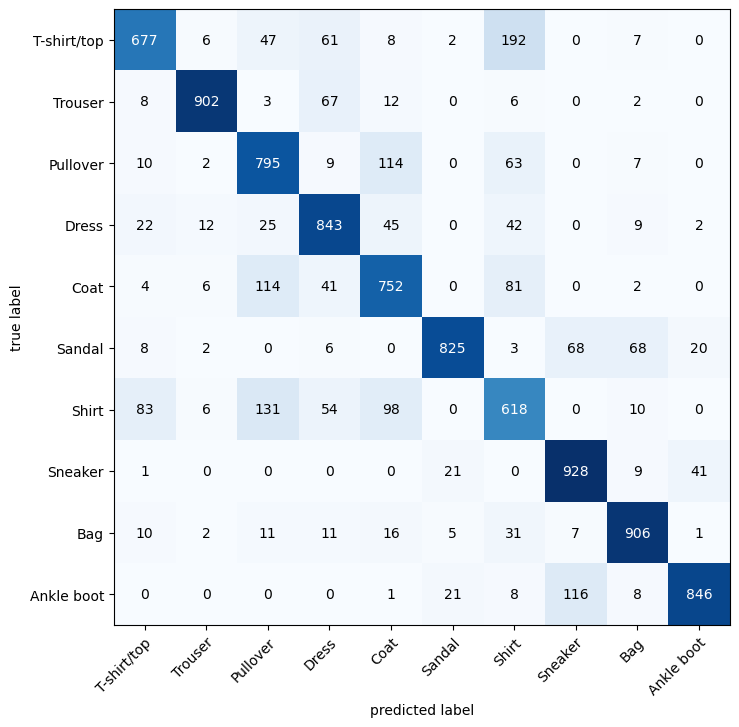

In [39]:
from mlxtend.plotting import plot_confusion_matrix
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
#2.setup instacne and  compare predcitons to target
confmat = ConfusionMatrix(task= 'multiclass',num_classes = len(class_names))
confmat_tensor = confmat(preds = y_preds_tensor,
                        target = test_data.targets)

#3.Plot the cinfusin matrix
fig , ax = plot_confusion_matrix(
    conf_mat= confmat_tensor.numpy(), #Matplot lib only takes numpy arrays for plotting
    class_names = class_names,\
    figsize=(10,8)
)   